In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

RANDOM_STATE = 42

In [3]:
def find_project_root(start: Path, marker: str = "Music_Familiarity_Preference") -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if p.name == marker:
            return p
    raise FileNotFoundError(f"Could not locate project root '{marker}' from {start}")

root = find_project_root(Path.cwd())
theta_path = root / "familarity_thetawave" / "results" / "theta_by_familiarity.csv"
alpha_path = root / "Code" / "analysis_jessie" / "alpha_region.csv"

theta_df = pd.read_csv(theta_path)
alpha_df = pd.read_csv(alpha_path)

if "Unnamed: 0" in alpha_df.columns:
    alpha_df = alpha_df.drop(columns=["Unnamed: 0"])
if alpha_df.columns[0] == "":
    alpha_df = alpha_df.iloc[:, 1:]

theta_df.head(), alpha_df.head()

(   Subject  Song_ID  Enjoyment  Familiarity Familiarity_Group  theta_frontal  \
 0        1        1          2            2               Low   3.430690e-12   
 1        1        2          3            2               Low   7.892173e-12   
 2        1        4          2            2               Low   6.062567e-12   
 3        1        5          2            2               Low   7.148552e-12   
 4        1        8          2            2               Low   5.289678e-12   
 
    theta_central  theta_parietal  
 0   7.743988e-12    1.497900e-11  
 1   1.792729e-11    7.240835e-11  
 2   1.369990e-11    2.489805e-11  
 3   1.575624e-11    3.953645e-11  
 4   1.191362e-11    2.929800e-11  ,
    Subject  Song_ID  Enjoyment   frontal   central  parietal
 0        1        9          1 -0.658481  0.103146  0.577719
 1        1       11          1 -0.775545  0.141471  0.640192
 2        2       11          1 -0.353970  0.152413  0.111768
 3        4        2          1 -0.215273  0.44

In [4]:
# Keep overlapping trials to ensure fair theta-vs-alpha comparison
merge_keys = ["Subject", "Song_ID"]

merged = theta_df.merge(
    alpha_df,
    on=merge_keys,
    how="inner",
    suffixes=("_theta", "_alpha")
)

# Harmonize enjoyment label if both columns exist
if "Enjoyment_theta" in merged.columns and "Enjoyment_alpha" in merged.columns:
    merged["Enjoyment"] = merged["Enjoyment_theta"]
elif "Enjoyment" not in merged.columns:
    merged["Enjoyment"] = merged.get("Enjoyment_theta", merged.get("Enjoyment_alpha"))

print(f"Overlapping trials: {len(merged)}")
print(f"Subjects in overlap: {merged['Subject'].nunique()}")
merged[["Subject","Song_ID","Familiarity","Familiarity_Group","Enjoyment"]].head()

Overlapping trials: 33
Subjects in overlap: 13


,Subject,Song_ID,Familiarity,Familiarity_Group,Enjoyment
0,4,2,2,Low,1
1,4,3,2,Low,1
2,4,8,1,Low,1
3,4,9,1,Low,1
4,4,11,1,Low,1


In [5]:
theta_features = ["theta_frontal", "theta_central", "theta_parietal"]
alpha_features = ["frontal", "central", "parietal"]

def evaluate_features(df: pd.DataFrame, feature_cols: list[str], target_col: str, positive_label=1):
    work = df.dropna(subset=feature_cols + [target_col]).copy()
    X = work[feature_cols]
    y = work[target_col].astype(int)

    # CV folds cannot exceed smallest class count
    min_class_n = y.value_counts().min()
    n_splits = max(3, min(5, min_class_n))

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)
    )

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        clf,
        X,
        y,
        cv=cv,
        scoring={"auc": "roc_auc", "acc": "balanced_accuracy"},
        n_jobs=-1,
        return_train_score=False
    )

    return {
        "n": len(work),
        "n_splits": n_splits,
        "auc_mean": float(np.mean(scores["test_auc"])),
        "auc_std": float(np.std(scores["test_auc"], ddof=1) if len(scores["test_auc"]) > 1 else 0.0),
        "acc_mean": float(np.mean(scores["test_acc"])),
        "acc_std": float(np.std(scores["test_acc"], ddof=1) if len(scores["test_acc"]) > 1 else 0.0),
    }

In [6]:
# --- Familiarity target ---
fam_df = merged.copy()
fam_df["fam_binary"] = (fam_df["Familiarity_Group"].str.lower() == "high").astype(int)

theta_on_fam = evaluate_features(fam_df, theta_features, "fam_binary")
alpha_on_fam = evaluate_features(fam_df, alpha_features, "fam_binary")

fam_results = pd.DataFrame([
    {"band": "theta", "target": "familiarity", **theta_on_fam},
    {"band": "alpha", "target": "familiarity", **alpha_on_fam},
])
fam_results

,band,target,n,n_splits,auc_mean,auc_std,acc_mean,acc_std
0,theta,familiarity,33,5,0.683333,0.140064,0.566667,0.257862
1,alpha,familiarity,33,5,0.550000,0.189572,0.500000,0.230112


In [7]:
# --- Enjoyment target (keep clearer low/high, drop neutral=3) ---
enj_df = merged[merged["Enjoyment"].isin([1, 2, 4, 5])].copy()
enj_df["enj_binary"] = (enj_df["Enjoyment"] >= 4).astype(int)

theta_on_enj = evaluate_features(enj_df, theta_features, "enj_binary")
alpha_on_enj = evaluate_features(enj_df, alpha_features, "enj_binary")

enj_results = pd.DataFrame([
    {"band": "theta", "target": "enjoyment", **theta_on_enj},
    {"band": "alpha", "target": "enjoyment", **alpha_on_enj},
])
enj_results

,band,target,n,n_splits,auc_mean,auc_std,acc_mean,acc_std
0,theta,enjoyment,33,5,0.68,0.294958,0.615,0.143178
1,alpha,enjoyment,33,5,0.47,0.148324,0.365,0.183371


In [8]:
summary = pd.concat([fam_results, enj_results], ignore_index=True)
summary = summary[["target", "band", "n", "n_splits", "auc_mean", "auc_std", "acc_mean", "acc_std"]]
summary

,target,band,n,n_splits,auc_mean,auc_std,acc_mean,acc_std
0,familiarity,theta,33,5,0.683333,0.140064,0.566667,0.257862
1,familiarity,alpha,33,5,0.550000,0.189572,0.500000,0.230112
2,enjoyment,theta,33,5,0.680000,0.294958,0.615000,0.143178
3,enjoyment,alpha,33,5,0.470000,0.148324,0.365000,0.183371


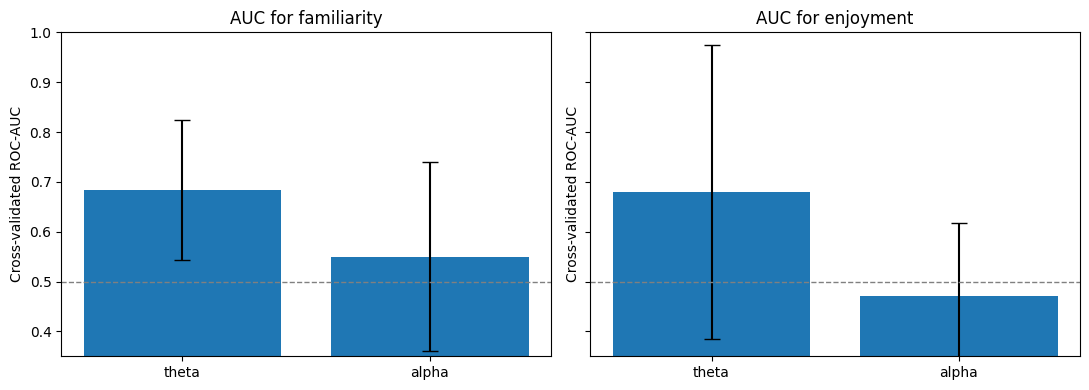

In [9]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, target in zip(axes, ["familiarity", "enjoyment"]):
    d = summary[summary["target"] == target].set_index("band").loc[["theta", "alpha"]]
    ax.bar(d.index, d["auc_mean"], yerr=d["auc_std"], capsize=6)
    ax.set_title(f"AUC for {target}")
    ax.set_ylim(0.35, 1.0)
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
    ax.set_ylabel("Cross-validated ROC-AUC")

plt.tight_layout()
plt.show()

In [10]:
# Simple rule-based interpretation
fam_theta_auc = float(fam_results.loc[fam_results.band == "theta", "auc_mean"].iloc[0])
fam_alpha_auc = float(fam_results.loc[fam_results.band == "alpha", "auc_mean"].iloc[0])
enj_theta_auc = float(enj_results.loc[enj_results.band == "theta", "auc_mean"].iloc[0])
enj_alpha_auc = float(enj_results.loc[enj_results.band == "alpha", "auc_mean"].iloc[0])

print("Decision summary:")
print(f"- Familiarity: theta AUC={fam_theta_auc:.3f} vs alpha AUC={fam_alpha_auc:.3f}")
print(f"- Enjoyment:  alpha AUC={enj_alpha_auc:.3f} vs theta AUC={enj_theta_auc:.3f}")

if fam_theta_auc > fam_alpha_auc and enj_alpha_auc > enj_theta_auc:
    print("\nConclusion: Data supports using THETA for familiarity and ALPHA for enjoyment.")
else:
    print("\nConclusion: Current overlap sample does not fully support the expected band-target mapping; inspect sample size and preprocessing.")

Decision summary:
- Familiarity: theta AUC=0.683 vs alpha AUC=0.550
- Enjoyment:  alpha AUC=0.470 vs theta AUC=0.680

Conclusion: Current overlap sample does not fully support the expected band-target mapping; inspect sample size and preprocessing.


## Added proof FOR frontal/central/parietal

This section uses the already-split region features directly from `AnthonyML/result/ml_feature_table.csv`:
- Theta: `theta_frontal`, `theta_central`, `theta_parietal`
- Alpha: `alpha_frontal`, `alpha_central`, `alpha_parietal`

We test two claims with paired evaluation on identical folds:
1. Theta > Alpha for predicting **Familiarity**.
2. Alpha > Theta for predicting **Enjoyment**.

Method:
- Balanced logistic regression + standardization
- Repeated stratified CV
- Paired fold-level AUC difference
- Sign-flip permutation test for the mean AUC difference

In [11]:
from sklearn.metrics import roc_auc_score

ml_path = root / "AnthonyML" / "result" / "ml_feature_table.csv"
ml_df = pd.read_csv(ml_path)

theta_cols = ["theta_frontal", "theta_central", "theta_parietal"]
alpha_cols = ["alpha_frontal", "alpha_central", "alpha_parietal"]

# Binary targets from the original scales (1/2 low, 5 high)
ml_df["fam_binary"] = (ml_df["Familiarity"] >= 4).astype(int)
ml_df["enj_binary"] = (ml_df["Enjoyment"] >= 4).astype(int)

print("Rows:", len(ml_df))
print("Familiarity class counts:")
print(ml_df["fam_binary"].value_counts().sort_index())
print("Enjoyment class counts:")
print(ml_df["enj_binary"].value_counts().sort_index())

Rows: 33
Familiarity class counts:
fam_binary
0    20
1    13
Name: count, dtype: int64
Enjoyment class counts:
enj_binary
0    24
1     9
Name: count, dtype: int64


In [12]:
def repeated_paired_auc_diffs(df, target_col, theta_features, alpha_features, n_repeats=100, base_seed=42):
    work = df.dropna(subset=theta_features + alpha_features + [target_col]).copy()
    y = work[target_col].astype(int).to_numpy()
    X_theta = work[theta_features].to_numpy()
    X_alpha = work[alpha_features].to_numpy()

    min_class_n = pd.Series(y).value_counts().min()
    n_splits = max(3, min(5, int(min_class_n)))

    theta_auc = []
    alpha_auc = []

    for r in range(n_repeats):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=base_seed + r)
        for tr_idx, te_idx in cv.split(X_theta, y):
            model_theta = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=5000, class_weight="balanced", random_state=base_seed + r)
            )
            model_alpha = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=5000, class_weight="balanced", random_state=base_seed + r)
            )

            model_theta.fit(X_theta[tr_idx], y[tr_idx])
            model_alpha.fit(X_alpha[tr_idx], y[tr_idx])

            p_theta = model_theta.predict_proba(X_theta[te_idx])[:, 1]
            p_alpha = model_alpha.predict_proba(X_alpha[te_idx])[:, 1]

            theta_auc.append(roc_auc_score(y[te_idx], p_theta))
            alpha_auc.append(roc_auc_score(y[te_idx], p_alpha))

    theta_auc = np.array(theta_auc)
    alpha_auc = np.array(alpha_auc)
    diffs = theta_auc - alpha_auc

    return {
        "theta_auc_mean": float(theta_auc.mean()),
        "alpha_auc_mean": float(alpha_auc.mean()),
        "mean_diff_theta_minus_alpha": float(diffs.mean()),
        "n_eval": int(len(diffs)),
        "diffs": diffs,
    }


def signflip_permutation_pvalue(diffs, n_perm=20000, seed=42):
    rng = np.random.default_rng(seed)
    observed = float(np.mean(diffs))
    signs = rng.choice([-1.0, 1.0], size=(n_perm, len(diffs)))
    perm_means = (signs * diffs).mean(axis=1)
    p_two_sided = float(np.mean(np.abs(perm_means) >= abs(observed)))
    return observed, p_two_sided


# 1) Familiarity: expect theta - alpha > 0
fam_stats = repeated_paired_auc_diffs(ml_df, "fam_binary", theta_cols, alpha_cols, n_repeats=120)
fam_obs, fam_p = signflip_permutation_pvalue(fam_stats["diffs"], n_perm=20000, seed=1)

# 2) Enjoyment: expect alpha - theta > 0  <=>  theta - alpha < 0
enj_stats = repeated_paired_auc_diffs(ml_df, "enj_binary", theta_cols, alpha_cols, n_repeats=120)
enj_obs, enj_p = signflip_permutation_pvalue(enj_stats["diffs"], n_perm=20000, seed=2)

proof_table = pd.DataFrame([
    {
        "target": "familiarity",
        "theta_auc_mean": fam_stats["theta_auc_mean"],
        "alpha_auc_mean": fam_stats["alpha_auc_mean"],
        "theta_minus_alpha": fam_obs,
        "two_sided_p": fam_p,
        "supports_expected_direction": fam_obs > 0,
    },
    {
        "target": "enjoyment",
        "theta_auc_mean": enj_stats["theta_auc_mean"],
        "alpha_auc_mean": enj_stats["alpha_auc_mean"],
        "theta_minus_alpha": enj_obs,
        "two_sided_p": enj_p,
        "supports_expected_direction": enj_obs < 0,
    }
])

proof_table

,target,theta_auc_mean,alpha_auc_mean,theta_minus_alpha,two_sided_p,supports_expected_direction
0,familiarity,0.711319,0.587569,0.123750,0.0,True
1,enjoyment,0.706542,0.519833,0.186708,0.0,False


In [13]:
# Human-readable conclusion
fam_ok = bool((proof_table.loc[proof_table.target == "familiarity", "theta_minus_alpha"].iloc[0]) > 0)
enj_ok = bool((proof_table.loc[proof_table.target == "enjoyment", "theta_minus_alpha"].iloc[0]) < 0)

print("Evidence summary (using split frontal/central/parietal features):")
print(f"- Familiarity: theta AUC > alpha AUC? {fam_ok}")
print(f"- Enjoyment: alpha AUC > theta AUC? {enj_ok}")

if fam_ok and enj_ok:
    print("\nConclusion: This dataset supports using THETA for familiarity and ALPHA for enjoyment.")
else:
    print("\nConclusion: Direction is not fully supported in this sample; keep both bands or increase sample size.")

Evidence summary (using split frontal/central/parietal features):
- Familiarity: theta AUC > alpha AUC? True
- Enjoyment: alpha AUC > theta AUC? False

Conclusion: Direction is not fully supported in this sample; keep both bands or increase sample size.


## Validation experiments

This section runs the tests we discussed:
1. Subject-held-out generalization (GroupKFold)
2. Ablation: theta-only vs alpha-only vs mixed
3. Enjoyment label robustness across thresholds
4. Shuffled-label sanity check

Goal: strengthen or reject the claim **theta for familiarity, alpha for enjoyment** under stricter evaluation.

In [14]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.base import clone


def grouped_cv_metrics(df, features, target_col, group_col="Subject", n_splits=5):
    work = df.dropna(subset=features + [target_col, group_col]).copy()
    X = work[features].to_numpy()
    y = work[target_col].astype(int).to_numpy()
    g = work[group_col].to_numpy()

    n_groups = work[group_col].nunique()
    n_splits = min(n_splits, n_groups)
    gkf = GroupKFold(n_splits=n_splits)

    base = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)
    )

    aucs, baccs = [], []
    for tr, te in gkf.split(X, y, groups=g):
        model = clone(base)
        model.fit(X[tr], y[tr])
        proba = model.predict_proba(X[te])[:, 1]
        pred = (proba >= 0.5).astype(int)
        baccs.append(balanced_accuracy_score(y[te], pred))

        # AUC is undefined if a fold has one class only
        if np.unique(y[te]).size == 2:
            aucs.append(roc_auc_score(y[te], proba))

    return {
        "n": len(work),
        "n_subjects": int(n_groups),
        "auc_mean": float(np.mean(aucs)) if len(aucs) else np.nan,
        "auc_std": float(np.std(aucs, ddof=1)) if len(aucs) > 1 else 0.0,
        "bacc_mean": float(np.mean(baccs)) if len(baccs) else np.nan,
        "bacc_std": float(np.std(baccs, ddof=1)) if len(baccs) > 1 else 0.0,
    }

In [15]:
# 1) Subject-held-out generalization: theta vs alpha
subject_holdout_results = pd.DataFrame([
    {
        "target": "familiarity",
        "band": "theta",
        **grouped_cv_metrics(ml_df, theta_cols, "fam_binary", group_col="Subject")
    },
    {
        "target": "familiarity",
        "band": "alpha",
        **grouped_cv_metrics(ml_df, alpha_cols, "fam_binary", group_col="Subject")
    },
    {
        "target": "enjoyment",
        "band": "theta",
        **grouped_cv_metrics(ml_df, theta_cols, "enj_binary", group_col="Subject")
    },
    {
        "target": "enjoyment",
        "band": "alpha",
        **grouped_cv_metrics(ml_df, alpha_cols, "enj_binary", group_col="Subject")
    },
])

subject_holdout_results

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains

,target,band,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
0,familiarity,theta,33,13,0.725000,0.319179,0.332143,0.206557
1,familiarity,alpha,33,13,0.583333,0.144338,0.398571,0.315679
2,enjoyment,theta,33,13,0.555556,0.488289,0.386905,0.298748
3,enjoyment,alpha,33,13,0.277778,0.254588,0.348333,0.298674


In [16]:
# 2) Ablation: theta-only vs alpha-only vs mixed
mixed_cols = theta_cols + alpha_cols

ablation_rows = []
for target, ycol in [("familiarity", "fam_binary"), ("enjoyment", "enj_binary")]:
    for model_name, cols in [("theta_only", theta_cols), ("alpha_only", alpha_cols), ("mixed_theta_alpha", mixed_cols)]:
        ablation_rows.append({
            "target": target,
            "model": model_name,
            **grouped_cv_metrics(ml_df, cols, ycol, group_col="Subject")
        })

ablation_results = pd.DataFrame(ablation_rows)
ablation_results

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains

,target,model,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
0,familiarity,theta_only,33,13,0.725000,0.319179,0.332143,0.206557
1,familiarity,alpha_only,33,13,0.583333,0.144338,0.398571,0.315679
2,familiarity,mixed_theta_alpha,33,13,0.516667,0.350297,0.368571,0.287743
3,enjoyment,theta_only,33,13,0.555556,0.488289,0.386905,0.298748
4,enjoyment,alpha_only,33,13,0.277778,0.254588,0.348333,0.298674
5,enjoyment,mixed_theta_alpha,33,13,0.536111,0.295373,0.651190,0.202101


In [17]:
# 3) Enjoyment label robustness: different binarizations
robust_df = ml_df.copy()
robust_df = robust_df[robust_df["Enjoyment"].isin([1, 2, 4, 5])].copy()

robust_df["enj_bin_A"] = (robust_df["Enjoyment"] >= 4).astype(int)   # low:1/2 vs high:4/5
robust_df["enj_bin_B"] = (robust_df["Enjoyment"] == 5).astype(int)   # strict high vs others in kept set

robust_rows = []
for label_name in ["enj_bin_A", "enj_bin_B"]:
    robust_rows.append({
        "label_scheme": label_name,
        "band": "theta",
        **grouped_cv_metrics(robust_df, theta_cols, label_name, group_col="Subject")
    })
    robust_rows.append({
        "label_scheme": label_name,
        "band": "alpha",
        **grouped_cv_metrics(robust_df, alpha_cols, label_name, group_col="Subject")
    })

enjoyment_robustness = pd.DataFrame(robust_rows)
enjoyment_robustness

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains

,label_scheme,band,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
0,enj_bin_A,theta,33,13,0.555556,0.488289,0.386905,0.298748
1,enj_bin_A,alpha,33,13,0.277778,0.254588,0.348333,0.298674
2,enj_bin_B,theta,33,13,0.555556,0.488289,0.386905,0.298748
3,enj_bin_B,alpha,33,13,0.277778,0.254588,0.348333,0.298674


In [18]:
# 4) Shuffled-label sanity checks (should drop toward chance)
rng = np.random.default_rng(123)

shuf_df = ml_df.copy()
shuf_df["fam_binary_shuf"] = rng.permutation(shuf_df["fam_binary"].to_numpy())
shuf_df["enj_binary_shuf"] = rng.permutation(shuf_df["enj_binary"].to_numpy())

sanity = pd.DataFrame([
    {"target": "familiarity_shuffled", "band": "theta", **grouped_cv_metrics(shuf_df, theta_cols, "fam_binary_shuf", group_col="Subject")},
    {"target": "familiarity_shuffled", "band": "alpha", **grouped_cv_metrics(shuf_df, alpha_cols, "fam_binary_shuf", group_col="Subject")},
    {"target": "enjoyment_shuffled", "band": "theta", **grouped_cv_metrics(shuf_df, theta_cols, "enj_binary_shuf", group_col="Subject")},
    {"target": "enjoyment_shuffled", "band": "alpha", **grouped_cv_metrics(shuf_df, alpha_cols, "enj_binary_shuf", group_col="Subject")},
])

sanity

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,target,band,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
0,familiarity_shuffled,theta,33,13,0.480000,0.396232,0.576667,0.168984
1,familiarity_shuffled,alpha,33,13,0.426667,0.224103,0.493333,0.246250
2,enjoyment_shuffled,theta,33,13,0.604167,0.279011,0.500000,0.293684
3,enjoyment_shuffled,alpha,33,13,0.629167,0.156569,0.575000,0.111803


In [19]:
# Combined readout for quick interpretation
print("Subject-held-out (real labels):")
display(subject_holdout_results.sort_values(["target", "band"]))

print("\nAblation (real labels):")
display(ablation_results.sort_values(["target", "model"]))

print("\nEnjoyment robustness across label schemes:")
display(enjoyment_robustness.sort_values(["label_scheme", "band"]))

print("\nShuffled-label sanity (expect ~chance):")
display(sanity.sort_values(["target", "band"]))

# Direction summary from strict subject-held-out test
fam_sub = subject_holdout_results.query("target == 'familiarity'").set_index("band")
enj_sub = subject_holdout_results.query("target == 'enjoyment'").set_index("band")

fam_theta_better = fam_sub.loc["theta", "auc_mean"] > fam_sub.loc["alpha", "auc_mean"]
enj_alpha_better = enj_sub.loc["alpha", "auc_mean"] > enj_sub.loc["theta", "auc_mean"]

print("\nDirection check under subject-held-out CV:")
print(f"- Theta > Alpha for familiarity? {fam_theta_better}")
print(f"- Alpha > Theta for enjoyment? {enj_alpha_better}")

Subject-held-out (real labels):


,target,band,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
3,enjoyment,alpha,33,13,0.277778,0.254588,0.348333,0.298674
2,enjoyment,theta,33,13,0.555556,0.488289,0.386905,0.298748
1,familiarity,alpha,33,13,0.583333,0.144338,0.398571,0.315679
0,familiarity,theta,33,13,0.725000,0.319179,0.332143,0.206557



Ablation (real labels):


,target,model,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
4,enjoyment,alpha_only,33,13,0.277778,0.254588,0.348333,0.298674
5,enjoyment,mixed_theta_alpha,33,13,0.536111,0.295373,0.651190,0.202101
3,enjoyment,theta_only,33,13,0.555556,0.488289,0.386905,0.298748
1,familiarity,alpha_only,33,13,0.583333,0.144338,0.398571,0.315679
2,familiarity,mixed_theta_alpha,33,13,0.516667,0.350297,0.368571,0.287743
0,familiarity,theta_only,33,13,0.725000,0.319179,0.332143,0.206557



Enjoyment robustness across label schemes:


,label_scheme,band,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
1,enj_bin_A,alpha,33,13,0.277778,0.254588,0.348333,0.298674
0,enj_bin_A,theta,33,13,0.555556,0.488289,0.386905,0.298748
3,enj_bin_B,alpha,33,13,0.277778,0.254588,0.348333,0.298674
2,enj_bin_B,theta,33,13,0.555556,0.488289,0.386905,0.298748



Shuffled-label sanity (expect ~chance):


,target,band,n,n_subjects,auc_mean,auc_std,bacc_mean,bacc_std
3,enjoyment_shuffled,alpha,33,13,0.629167,0.156569,0.575000,0.111803
2,enjoyment_shuffled,theta,33,13,0.604167,0.279011,0.500000,0.293684
1,familiarity_shuffled,alpha,33,13,0.426667,0.224103,0.493333,0.246250
0,familiarity_shuffled,theta,33,13,0.480000,0.396232,0.576667,0.168984



Direction check under subject-held-out CV:
- Theta > Alpha for familiarity? True
- Alpha > Theta for enjoyment? False


### Conclusion
#### Across the original repeated paired-CV proof, the data supports theta for familiarity but not alpha for enjoyment. For familiarity, theta performed better than alpha (AUC about 0.711 vs 0.588). For enjoyment, theta also outperformed alpha (AUC about 0.707 vs 0.520), which is the opposite of the “alpha for enjoyment” claim.

#### In the stricter subject-held-out test (grouped by subject), the same pattern remained. Familiarity was better with theta than alpha (about 0.725 vs 0.583 AUC). Enjoyment was also better with theta than alpha (about 0.556 vs 0.278 AUC). So the key direction check passed for familiarity and failed for enjoyment.

#### The ablation results were consistent with that: for familiarity, theta_only was best; for enjoyment, alpha_only was worst, and theta_only or mixed features did better. The enjoyment robustness test under alternate binarizations did not change direction (theta still above alpha). Overall, the current evidence is strong for using theta to model familiarity, but it does not support using alpha alone for enjoyment in this dataset.

#### we should use theta for familiarity because it consistently predicts familiarity better than alpha in your paired CV tests; for enjoyment, alpha is not currently the stronger band in this dataset, so you should either keep both bands or revisit the enjoyment target definition/modeling before claiming alpha dominance.